# 09 Basic Polymer Analysis

This notebook is a practical starting point for basic structural analysis of a centered polymer trajectory from `08_trajectory_preprocessing.ipynb`.

## Analysis input policy

Use `step7_centered.xtc` as the default preprocessed trajectory.

Do not use raw `step7_production.xtc` directly for these basic analyses. Raw periodic trajectories can contain broken molecules, box jumps, and whole-system drift.

In [13]:
from pathlib import Path

SYSTEM_DIR = Path("/Users/k20098771/Data/MD_projects/PHA/MD/gromacs/PHB4_01")
ANALYSIS_TRAJECTORY = SYSTEM_DIR / "step7_centered.xtc"
STRUCTURE = SYSTEM_DIR / "step6.2_npt.gro"
CENTER_INDEX = SYSTEM_DIR / "center.ndx"

analysis_inputs = {
    "analysis_trajectory": ANALYSIS_TRAJECTORY,
    "structure_for_mdtraj": STRUCTURE,
    "center_index": CENTER_INDEX,
}

for label, path in analysis_inputs.items():
    print(f"{label:20s} {path.exists()}  {path}")

analysis_trajectory  True  /Users/k20098771/Data/MD_projects/PHA/MD/gromacs/PHB4_01/step7_centered.xtc
structure_for_mdtraj True  /Users/k20098771/Data/MD_projects/PHA/MD/gromacs/PHB4_01/step6.2_npt.gro
center_index         True  /Users/k20098771/Data/MD_projects/PHA/MD/gromacs/PHB4_01/center.ndx


In [14]:
if not ANALYSIS_TRAJECTORY.exists():
    raise FileNotFoundError(
        "Missing centered analysis trajectory. Run 08_trajectory_preprocessing.ipynb first. "
        f"Expected: {ANALYSIS_TRAJECTORY}"
    )

if not STRUCTURE.exists():
    raise FileNotFoundError(
        "Missing GRO structure file needed by MDTraj to load the trajectory. "
        f"Expected: {STRUCTURE}"
    )


if not CENTER_INDEX.exists():
    raise FileNotFoundError(
        "Missing center index file needed to select polymer atoms. "
        f"Expected: {CENTER_INDEX}"
    )


## Load centered trajectory

The cell below is the analysis entry point. It deliberately loads the centered trajectory, not the raw production trajectory.

In [15]:
try:
    import matplotlib.pyplot as plt
    import mdtraj as md
    import pandas as pd
except ImportError as exc:
    raise ImportError("Install the md optional dependencies and matplotlib to run analysis cells.") from exc

trajectory = md.load(str(ANALYSIS_TRAJECTORY), top=str(STRUCTURE))
trajectory

<mdtraj.Trajectory with 50001 frames, 7394 atoms, 2458 residues, and unitcells at 0x17f615910>

## Subsample frames for analysis

Large trajectories can be expensive to analyze frame-by-frame. Subsampling with `trajectory[::100]` keeps every 100th frame, which is often enough for quick exploratory plots.

In [16]:
analysis_trajectory = trajectory[::100]
time_ns = analysis_trajectory.time / 1000.0

analysis_table = pd.DataFrame({"time_ns": time_ns})
{
    "loaded_frames": trajectory.n_frames,
    "analysis_frames": analysis_trajectory.n_frames,
    "analysis_trajectory": ANALYSIS_TRAJECTORY,
}


{'loaded_frames': 50001,
 'analysis_frames': 501,
 'analysis_trajectory': PosixPath('/Users/k20098771/Data/MD_projects/PHA/MD/gromacs/PHB4_01/step7_centered.xtc')}

## Polymer atom selection

The `[ center ]` group from notebook 08 is used here as the polymer atom set for the basic analyses below.

In [17]:
from iphasimulator.trajectory import read_index

center_group = read_index(CENTER_INDEX).group("center")
polymer_atoms = [atom_id - 1 for atom_id in center_group]
polymer_trajectory = analysis_trajectory.atom_slice(polymer_atoms)

{
    "analysis_frames": analysis_trajectory.n_frames,
    "polymer_atoms": len(polymer_atoms),
}


{'analysis_frames': 501, 'polymer_atoms': 51}

## Radius of gyration (Rg)

Radius of gyration measures polymer compactness. It is useful for monitoring whether the chain is collapsing into a compact state or extending into a more open conformation. A rolling average helps show the trend, while a histogram shows the distribution of sampled conformations.

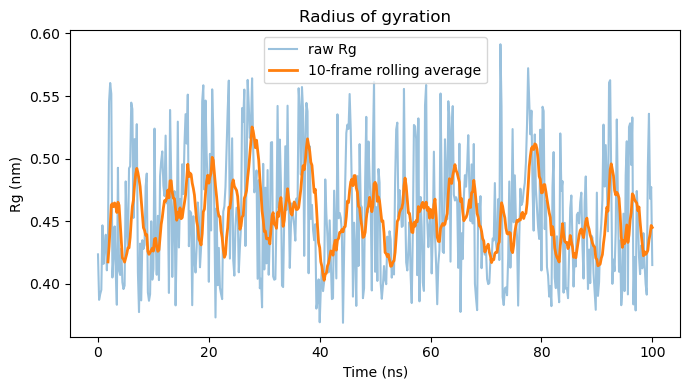

In [18]:
rg = md.compute_rg(polymer_trajectory)
window = 10
rg_smooth = pd.Series(rg).rolling(window).mean()

analysis_table["rg_nm"] = rg
analysis_table["rg_smooth_nm"] = rg_smooth

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(analysis_table["time_ns"], analysis_table["rg_nm"], label="raw Rg", alpha=0.45)
ax.plot(analysis_table["time_ns"], analysis_table["rg_smooth_nm"], label=f"{window}-frame rolling average", linewidth=2)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Rg (nm)")
ax.set_title("Radius of gyration")
ax.legend()
fig.tight_layout()
plt.show()


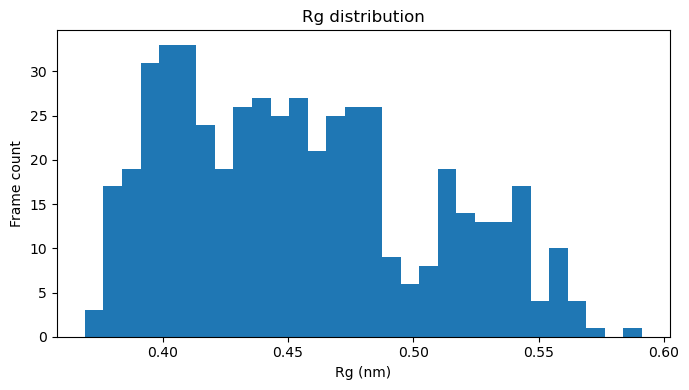

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rg, bins=30)
ax.set_xlabel("Rg (nm)")
ax.set_ylabel("Frame count")
ax.set_title("Rg distribution")
fig.tight_layout()
plt.show()


## End-to-end distance

As a simple chain-extension example, use the first and last polymer atoms from `[ center ]`. This tracks extension and flexibility, but for branched or complex polymers you may want a more chemically specific atom pair. A rolling average helps show the slower trend.

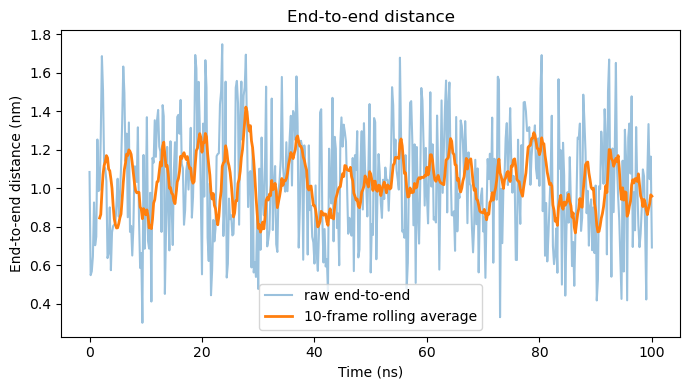

In [20]:
end_to_end_pair = [[polymer_atoms[0], polymer_atoms[-1]]]
analysis_table["end_to_end_nm"] = md.compute_distances(analysis_trajectory, end_to_end_pair)[:, 0]
analysis_table["end_to_end_smooth_nm"] = pd.Series(analysis_table["end_to_end_nm"]).rolling(window).mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(analysis_table["time_ns"], analysis_table["end_to_end_nm"], label="raw end-to-end", alpha=0.45)
ax.plot(analysis_table["time_ns"], analysis_table["end_to_end_smooth_nm"], label=f"{window}-frame rolling average", linewidth=2)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("End-to-end distance (nm)")
ax.set_title("End-to-end distance")
ax.legend()
fig.tight_layout()
plt.show()


## SASA

Solvent-accessible surface area (SASA) estimates how much of the polymer surface is exposed to solvent. Here SASA is computed on the polymer-only trajectory, so water and ions do not occlude polymer surface points. A rolling average helps show slower changes in solvent exposure.

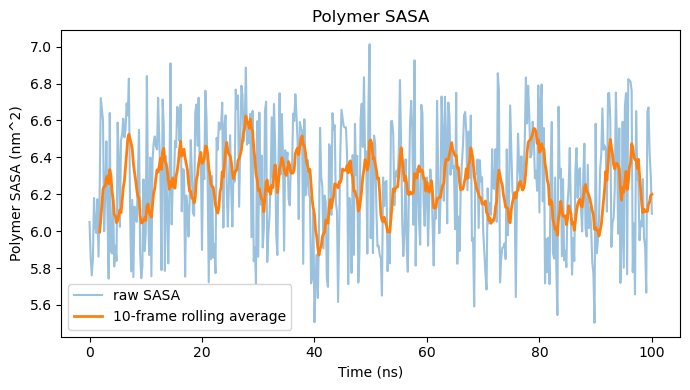

In [22]:
atom_sasa = md.shrake_rupley(
    polymer_trajectory,
    mode="atom",
    n_sphere_points=960,
)
polymer_sasa = atom_sasa.sum(axis=1)
polymer_sasa_smooth = pd.Series(polymer_sasa).rolling(window).mean()

analysis_table["polymer_sasa_nm2"] = polymer_sasa
analysis_table["polymer_sasa_smooth_nm2"] = polymer_sasa_smooth

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(analysis_table["time_ns"], analysis_table["polymer_sasa_nm2"], label="raw SASA", alpha=0.45)
ax.plot(analysis_table["time_ns"], analysis_table["polymer_sasa_smooth_nm2"], label=f"{window}-frame rolling average", linewidth=2)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Polymer SASA (nm^2)")
ax.set_title("Polymer SASA")
ax.legend()
fig.tight_layout()
plt.show()


Advanced clustering and ML analysis are intentionally left out until the preprocessing layer is validated on production outputs.